In [2]:
from pathlib import Path
from testing_calcs import read_audio_chunk, split_into_windows, compute_template_dtw_costs, load_threshold, load_template_segment
from IPython.display import Audio
from stft import stft_calculation, plot_spectrogram
import json

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

In [3]:
st_temps = RESULTS_29 / "20230429_Templates_20230429_102841_single_tone_templates.json"
mt_temps = RESULTS_29 / "20230429_Templates_20230429_102841_multi_tone_templates.json"
bt_temps = RESULTS_29 / "20230429_Templates_20230429_102841_burst_tonal_templates.json"

In [4]:
#load template data from .json file
with open(st_temps) as f:
    st_templates = json.load(f)

with open(mt_temps) as f:
    mt_templates = json.load(f)

with open(bt_temps) as f:
    bt_templates = json.load(f)

In [5]:
st_templates = st_templates[:5]
mt_templates = mt_templates[:5]
bt_templates = bt_templates[:5]

In [6]:
st_stfts = [load_template_segment(t, 1000) for t in st_templates]
mt_stfts = [load_template_segment(t, 1000) for t in mt_templates]
bt_stfts = [load_template_segment(t, 1000) for t in bt_templates]

Load thresholds

In [7]:
st = load_threshold(file_label = "20230429_Templates", 
               call_type = "single_tone", 
               results_dir = RESULTS_29)

st_threshold = st["threshold"]

mt = load_threshold(file_label = "20230429_Templates", 
               call_type = "multi_tone", 
               results_dir = RESULTS_29)

mt_threshold = mt["threshold"]

bt = load_threshold(file_label = "20230429_Templates", 
               call_type = "burst_tonal", 
               results_dir = RESULTS_29)

bt_threshold = bt["threshold"]

print(f"Single Tone Threshold: {st_threshold}")
print(f"Multi Tone Threshold: {mt_threshold}")
print(f"Burst Tonal Threshold: {bt_threshold}")

Single Tone Threshold: 0.16292170638658898
Multi Tone Threshold: 0.17513743191345682
Burst Tonal Threshold: 0.15166169445617353


Load 72 hour audio in 1 hour segments

In [8]:
#load 1 hour of audio and resample to fs = 1000Hz
f_s, audio_array = read_audio_chunk(DATA_22 / "20230422_171301.wav", 0.0)

Split Audio into windows

In [9]:
window_len = int(0.15*1000)
step_len = int(window_len/2)
windows = split_into_windows(audio_array, window_len, step_len)

In [10]:
print (len(windows))

47999


In [27]:
audio_segment = windows[24966][2]
f_win, t_win, Zxx_window = stft_calculation(audio_segment, f_s, f_s)

In [28]:
costs_st, costs_mt, costs_bt = compute_template_dtw_costs(st_stfts, 
                           mt_stfts, 
                           bt_stfts, 
                           n_templates = 5, 
                           audio_segment = Zxx_window)

In [29]:
calls = 0
for i in range(len(costs_st)):
    if costs_st[i] < st_threshold:
        print("st")
        calls = 1
        break
for i in range(len(costs_mt)):
    if costs_mt[i] < mt_threshold:
        print("mt")
        calls = 1
        break
for i in range(len(costs_bt)):
    if costs_bt[i] < bt_threshold:
        print("bt")
        calls = 1
        break
if calls == 0:
    print("not a call")
else:
    print("call detected")

mt
call detected


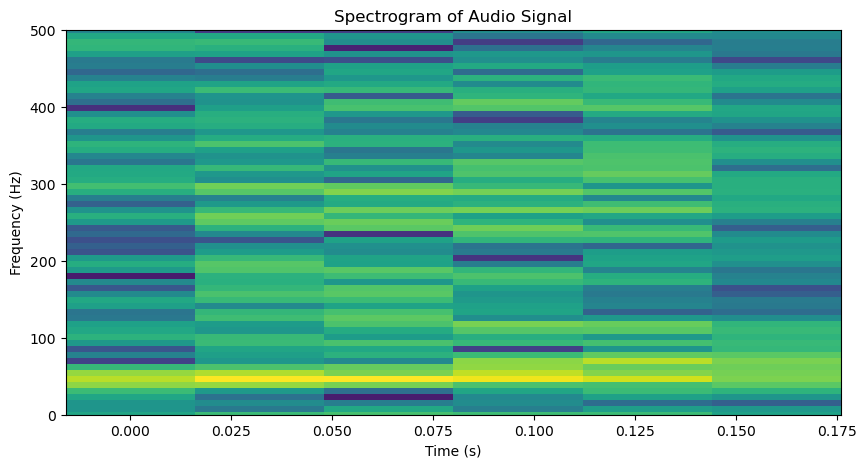

In [30]:
plot_spectrogram(f_win, t_win, Zxx_window, 1000)